In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px

In [2]:
result = pd.read_csv("results.csv")
result.fillna(0, inplace=True)
result

,pre,post,plen,threshold_0,threshold_0.001,threshold_0.01,threshold_0.03,threshold_0.05,threshold_0.1,effconn
0,AVLP169_right,CB0906_right,2,False,False,False,False,False,False,0.000000e+00
1,AVLP169_right,CB0906_right,3,True,True,False,False,False,False,2.329226e-07
2,AVLP169_right,CB0906_right,4,True,True,False,False,False,False,1.254350e-06
3,AVLP169_right,CB0906_right,5,True,True,True,False,False,False,3.028013e-06
4,AVLP169_right,CB3126_left,2,False,False,False,False,False,False,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...
3999995,AN_GNG_32_right,CB1676_left,5,True,True,True,False,False,False,2.438331e-06
3999996,AN_GNG_32_right,CB3343_right,2,False,False,False,False,False,False,0.000000e+00
3999997,AN_GNG_32_right,CB3343_right,3,True,True,False,False,False,False,7.366973e-06
3999998,AN_GNG_32_right,CB3343_right,4,True,True,False,False,False,False,1.064111e-05


In [3]:
# make longer: all columns starting with 'threshold'
result = result.melt(id_vars=['plen', 'effconn','pre','post'], value_vars=[col for col in result.columns if col.startswith('threshold')], var_name='threshold', value_name='value')
result['threshold'] = result['threshold'].str.replace('threshold_','')
result['path_length'] = result['plen'].astype(str)
result

,plen,effconn,pre,post,threshold,value,path_length
0,2,0.000000e+00,AVLP169_right,CB0906_right,0,False,2
1,3,2.329226e-07,AVLP169_right,CB0906_right,0,True,3
2,4,1.254350e-06,AVLP169_right,CB0906_right,0,True,4
3,5,3.028013e-06,AVLP169_right,CB0906_right,0,True,5
4,2,0.000000e+00,AVLP169_right,CB3126_left,0,False,2
...,...,...,...,...,...,...,...
23999995,5,2.438331e-06,AN_GNG_32_right,CB1676_left,0.1,False,5
23999996,2,0.000000e+00,AN_GNG_32_right,CB3343_right,0.1,False,2
23999997,3,7.366973e-06,AN_GNG_32_right,CB3343_right,0.1,False,3
23999998,4,1.064111e-05,AN_GNG_32_right,CB3343_right,0.1,False,4


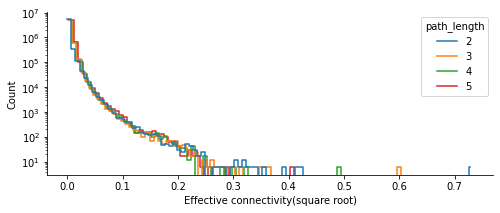

In [4]:
result["effconn_sqrt"] = np.sqrt(result["effconn"])

plt.figure(figsize=(8,3))
sns.histplot(
    data=result[result.effconn.notna()],
    x="effconn_sqrt",
    hue="path_length",
    bins=100,
    multiple="dodge",
    fill=False, 
    element="step",
)
plt.yscale("log")
plt.xlabel("Effective connectivity(square root)")
# remove upper and right borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

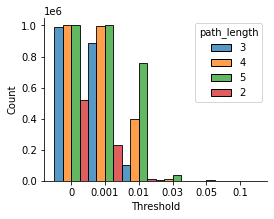

In [5]:
plt.figure(figsize=(4,3))
p = sns.histplot(
    result[result.value], x="threshold", hue="path_length", multiple="dodge"
)
# plt.yscale('log')
plt.xlabel("Threshold")
# remove upper and right borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

In [6]:
result[result.value][["path_length", "threshold"]].value_counts()

path_length  threshold
5            0            1000000
             0.001         999982
4            0             999972
             0.001         998353
3            0             992669
             0.001         888924
5            0.01          760192
2            0             517414
4            0.01          400361
2            0.001         231573
3            0.01          103861
5            0.03           35328
4            0.03           13874
2            0.01           13655
3            0.03            4646
5            0.05            3112
4            0.05            1778
2            0.03            1264
3            0.05             908
2            0.05             355
5            0.1              113
4            0.1               90
3            0.1               66
2            0.1               50
Name: count, dtype: int64